# Sentiment Analysis - Allociné (FR)

LSTM bidirectionnel avec embeddings FastText français pré-entraînés.
- **Dataset** : Allociné (2 classes : négatif / positif)
- **Modèle** : BiLSTM
- **Embeddings** : FastText FR pré-entraînés

In [4]:
import os
import logging
import time
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Setup logging
os.makedirs('logs', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(message)s',
    handlers=[
        logging.FileHandler('logs/sentiment_training.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

Using device: cuda:1


## 1. Téléchargement du dataset Allociné

In [5]:
!pip install datasets -q

In [6]:
from datasets import load_dataset

dataset = load_dataset('allocine')
print(dataset)
print(f"\nTrain: {len(dataset['train'])} samples")
print(f"Val:   {len(dataset['validation'])} samples")
print(f"Test:  {len(dataset['test'])} samples")
print(f"\nLabels: {set(dataset['train']['label'])} (0=négatif, 1=positif)")
print(f"\nExemple: {dataset['train'][0]['review'][:200]}...")
print(f"Label: {dataset['train'][0]['label']}")

2026-03-23 14:11:43,283 - HTTP Request: HEAD https://huggingface.co/datasets/allocine/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-03-23 14:11:43,490 - HTTP Request: HEAD https://huggingface.co/datasets/tblard/allocine/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-03-23 14:11:43,500 - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/tblard/allocine/a4654f4896408912913a62ace89614879a549287/README.md "HTTP/1.1 200 OK"
2026-03-23 14:11:43,500 - Task was destroyed but it is pending!
task: <Task pending name='Task-72' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/do5-ajlp/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-73' coro=<Kernel.shell_main() running at /home/do5-ajlp/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/do5-ajlp/lib/python3.12/site-packages/zmq/eventloop/zmqstream.

DatasetDict({
    train: Dataset({
        features: ['review', 'label'],
        num_rows: 160000
    })
    validation: Dataset({
        features: ['review', 'label'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['review', 'label'],
        num_rows: 20000
    })
})

Train: 160000 samples
Val:   20000 samples
Test:  20000 samples

Labels: {0, 1} (0=négatif, 1=positif)

Exemple: Si vous cherchez du cinéma abrutissant à tous les étages,n'ayant aucune peur du cliché en castagnettes et moralement douteux,"From Paris with love" est fait pour vous.Toutes les productions Besson,via...
Label: 0


## 2. Tokenization & Vocabulaire

In [7]:
import re

def tokenize(text):
    """Tokenization simple : lowercase + split sur non-alphanumérique."""
    text = text.lower()
    text = re.sub(r'[^a-zàâçéèêëïîôùûüÿñæœ0-9\s]', ' ', text)
    return text.split()

# Construire le vocabulaire sur le train set
word_counts = Counter()
for sample in tqdm(dataset['train'], desc='Building vocab'):
    word_counts.update(tokenize(sample['review']))

MIN_FREQ = 5
vocab = {'<pad>': 0, '<unk>': 1}
for word, count in word_counts.items():
    if count >= MIN_FREQ:
        vocab[word] = len(vocab)

print(f'Vocabulaire: {len(vocab)} mots (min_freq={MIN_FREQ})')

Building vocab:   0%|          | 0/160000 [00:00<?, ?it/s]

Vocabulaire: 52959 mots (min_freq=5)


## 3. Chargement des embeddings FastText

In [8]:
import gensim.downloader as api

# Telecharger les embeddings FastText francais (peut prendre quelques minutes)
print('Chargement des embeddings FastText FR...')
ft_model = api.load('fasttext-wiki-news-subwords-300')
EMBED_DIM = ft_model.vector_size
print(f'Embeddings chargés: dim={EMBED_DIM}')

Chargement des embeddings FastText FR...


2026-03-23 14:15:26,750 - loading projection weights from /home/do5-ajlp/gensim-data/fasttext-wiki-news-subwords-300/fasttext-wiki-news-subwords-300.gz
2026-03-23 14:18:47,945 - KeyedVectors lifecycle event {'msg': 'loaded (999999, 300) matrix of type float32 from /home/do5-ajlp/gensim-data/fasttext-wiki-news-subwords-300/fasttext-wiki-news-subwords-300.gz', 'binary': False, 'encoding': 'utf8', 'datetime': '2026-03-23T14:18:47.945169', 'gensim': '4.4.0', 'python': '3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]', 'platform': 'Linux-6.8.0-101-generic-x86_64-with-glibc2.39', 'event': 'load_word2vec_format'}


Embeddings chargés: dim=300


In [9]:
# Construire la matrice d'embeddings pour notre vocabulaire
embedding_matrix = np.zeros((len(vocab), EMBED_DIM), dtype=np.float32)
found = 0
for word, idx in vocab.items():
    if word in ft_model:
        embedding_matrix[idx] = ft_model[word]
        found += 1
    else:
        embedding_matrix[idx] = np.random.normal(0, 0.1, EMBED_DIM)

print(f'Embeddings trouvés: {found}/{len(vocab)} ({100*found/len(vocab):.1f}%)')

Embeddings trouvés: 24782/52959 (46.8%)


## 4. Dataset PyTorch

In [10]:
MAX_LEN = 256
NUM_CLASSES = 2

class AllocineDataset(Dataset):
    def __init__(self, hf_dataset, vocab, max_len=MAX_LEN):
        self.data = hf_dataset
        self.vocab = vocab
        self.max_len = max_len
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data[idx]
        tokens = tokenize(sample['review'])
        
        # Convertir en indices
        indices = [self.vocab.get(t, self.vocab['<unk>']) for t in tokens[:self.max_len]]
        
        # Longueur minimale de 1 pour eviter le crash de pack_padded_sequence
        if len(indices) == 0:
            indices = [self.vocab['<unk>']]
        length = len(indices)
        
        # Padding
        if length < self.max_len:
            indices += [self.vocab['<pad>']] * (self.max_len - length)
        
        return (
            torch.tensor(indices, dtype=torch.long),
            torch.tensor(length, dtype=torch.long),
            torch.tensor(sample['label'], dtype=torch.long)
        )

train_dataset = AllocineDataset(dataset['train'], vocab)
val_dataset = AllocineDataset(dataset['validation'], vocab)
test_dataset = AllocineDataset(dataset['test'], vocab)

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')

Train: 160000, Val: 20000, Test: 20000


## 5. Modèle BiLSTM

In [11]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=2,
                 dropout=0.3, pretrained_embeddings=None):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))
            self.embedding.weight.requires_grad = True  # fine-tune les embeddings
        
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # *2 pour bidirectionnel
    
    def forward(self, x, lengths):
        embedded = self.dropout(self.embedding(x))
        
        # Pack pour ignorer le padding
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        output, (hidden, _) = self.lstm(packed)
        
        # Concatener le dernier hidden state des deux directions
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        hidden = self.dropout(hidden)
        
        return self.fc(hidden)


# Test
model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=256,
    num_classes=NUM_CLASSES,
    pretrained_embeddings=embedding_matrix
).to(device)

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 18,608,470


## 6. Training Setup

In [12]:
# Hyperparameters
BATCH_SIZE = 128
NUM_EPOCHS = 30
LR = 1e-3
HIDDEN_DIM = 256

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    pretrained_embeddings=embedding_matrix
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print(f'Batches per epoch - Train: {len(train_loader)}, Val: {len(val_loader)}')
logger.info(f'Config: batch_size={BATCH_SIZE}, lr={LR}, hidden={HIDDEN_DIM}, max_len={MAX_LEN}, num_classes={NUM_CLASSES}')

2026-03-23 14:19:29,916 - Config: batch_size=128, lr=0.001, hidden=256, max_len=256, num_classes=2


Batches per epoch - Train: 1250, Val: 157


## 7. Training

In [13]:
def evaluate(model, loader):
    """Calcule la loss et l'accuracy sur un DataLoader."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for texts, lengths, labels in loader:
            texts, lengths, labels = texts.to(device), lengths.to(device), labels.to(device)
            outputs = model(texts, lengths)
            total_loss += criterion(outputs, labels).item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
early_stop_patience = 5
early_stop_min_delta = 0.001
stagnant_epochs = 0
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}', leave=True)
    for texts, lengths, labels in pbar:
        texts, lengths, labels = texts.to(device), lengths.to(device), labels.to(device)
        
        outputs = model(texts, lengths)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        pbar.set_postfix(loss=f'{epoch_loss/total:.4f}', acc=f'{correct/total:.4f}')
    
    train_loss = epoch_loss / total
    train_acc = correct / total
    val_loss, val_acc = evaluate(model, val_loader)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    scheduler.step(val_loss)
    
    log_msg = (f'Epoch {epoch+1}/{NUM_EPOCHS} - '
               f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} - '
               f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} - '
               f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
    print(f'  -> {log_msg}')
    logger.info(log_msg)
    
    # Checkpoint si meilleur val_loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
            'history': history,
            'vocab': vocab,
            'embed_dim': EMBED_DIM,
            'hidden_dim': HIDDEN_DIM,
        }, 'checkpoints/best_sentiment.pth')
        logger.info(f'Checkpoint saved (val_loss={val_loss:.4f}, val_acc={val_acc:.4f})')
    
    # Early stopping
    if len(history['val_loss']) >= 2:
        delta = history['val_loss'][-2] - history['val_loss'][-1]
        if delta < early_stop_min_delta:
            stagnant_epochs += 1
            if stagnant_epochs >= early_stop_patience:
                logger.info(f'Early stopping: val_loss stagnante depuis {early_stop_patience} epochs')
                print(f'Early stopping: val_loss stagnante depuis {early_stop_patience} epochs')
                break
        else:
            stagnant_epochs = 0

logger.info('Training finished')

Epoch 1/30:   0%|          | 0/1250 [00:00<?, ?it/s]

2026-03-23 14:20:47,033 - Epoch 1/30 - Train Loss: 0.2861 Acc: 0.8787 - Val Loss: 0.1784 Acc: 0.9308 - LR: 0.001000


  -> Epoch 1/30 - Train Loss: 0.2861 Acc: 0.8787 - Val Loss: 0.1784 Acc: 0.9308 - LR: 0.001000


2026-03-23 14:20:47,470 - Checkpoint saved (val_loss=0.1784, val_acc=0.9308)


Epoch 2/30:   0%|          | 0/1250 [00:00<?, ?it/s]

...

2026-03-23 14:26:32,397 - Epoch 6/30 - Train Loss: 0.0224 Acc: 0.9928 - Val Loss: 0.3200 Acc: 0.9267 - LR: 0.000500


  -> Epoch 6/30 - Train Loss: 0.0224 Acc: 0.9928 - Val Loss: 0.3200 Acc: 0.9267 - LR: 0.000500


Epoch 7/30:   0%|          | 0/1250 [00:00<?, ?it/s]

2026-03-23 14:27:43,104 - Epoch 7/30 - Train Loss: 0.0115 Acc: 0.9964 - Val Loss: 0.3911 Acc: 0.9297 - LR: 0.000500
2026-03-23 14:27:43,105 - Early stopping: val_loss stagnante depuis 5 epochs
2026-03-23 14:27:43,106 - Training finished


  -> Epoch 7/30 - Train Loss: 0.0115 Acc: 0.9964 - Val Loss: 0.3911 Acc: 0.9297 - LR: 0.000500
Early stopping: val_loss stagnante depuis 5 epochs


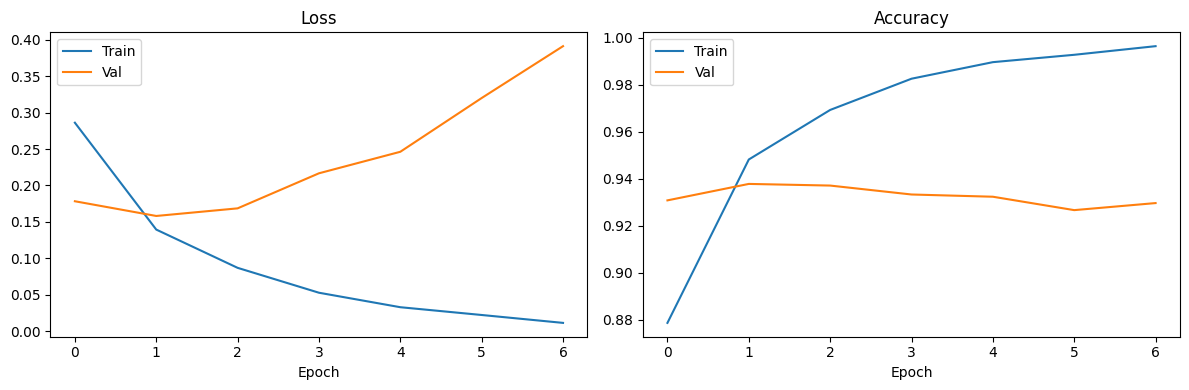

In [14]:
# Courbes de training
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.show()

In [15]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'vocab': vocab,
    'embed_dim': EMBED_DIM,
    'hidden_dim': HIDDEN_DIM,
}, 'checkpoints/best_sentiment.pth')
print('Model saved to checkpoints/best_sentiment.pth')

Model saved to checkpoints/best_sentiment.pth


In [16]:
# Charger le meilleur checkpoint
checkpoint = torch.load('checkpoints/best_sentiment.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Loaded best checkpoint (epoch {checkpoint["epoch"]}, val_acc={checkpoint["val_acc"]:.4f})')

test_loss, test_acc = evaluate(model, test_loader)
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')
logger.info(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')

KeyError: 'epoch'

              precision    recall  f1-score   support

     Négatif       0.94      0.93      0.94     10408
     Positif       0.93      0.94      0.93      9592

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



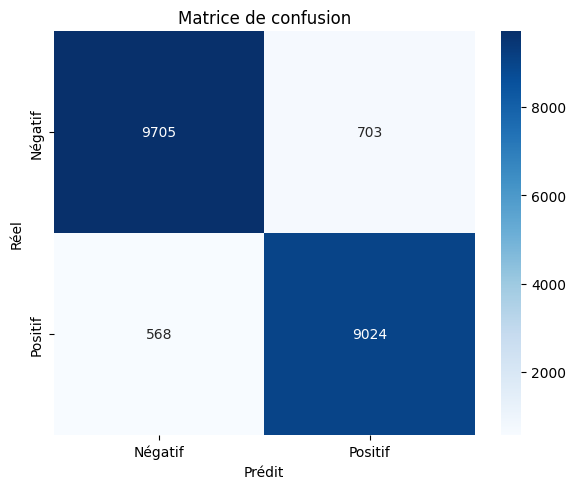

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predictions sur le test set
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for texts, lengths, labels in test_loader:
        texts, lengths = texts.to(device), lengths.to(device)
        outputs = model(texts, lengths)
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

label_names = ['Négatif', 'Positif']
print(classification_report(all_labels, all_preds, target_names=label_names))

# Matrice de confusion
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel'); ax.set_title('Matrice de confusion')
plt.tight_layout()
plt.show()

## 9. Tester sur vos propres phrases

In [18]:
def predict_sentiment(text):
    """Predit le sentiment d'un texte et affiche le resultat."""
    model.eval()
    tokens = tokenize(text)
    indices = [vocab.get(t, vocab['<unk>']) for t in tokens[:MAX_LEN]]
    if len(indices) == 0:
        indices = [vocab['<unk>']]
    length = len(indices)
    if length < MAX_LEN:
        indices += [vocab['<pad>']] * (MAX_LEN - length)
    
    x = torch.tensor([indices], dtype=torch.long).to(device)
    l = torch.tensor([length], dtype=torch.long).to(device)
    
    with torch.no_grad():
        output = model(x, l)
        probs = torch.softmax(output, dim=1).cpu().squeeze().numpy()
    
    labels = ['Négatif', 'Positif']
    pred = labels[probs.argmax()]
    
    print(f'Texte: "{text}"')
    print(f'Prediction: {pred}')
    for label, prob in zip(labels, probs):
        bar = '█' * int(prob * 30)
        print(f'  {label:>8}: {bar} {prob:.1%}')
    print()


predict_sentiment("Ce film est absolument magnifique, j'ai adoré !")
predict_sentiment("C'était pas mal mais sans plus.")
predict_sentiment("Quel navet, une perte de temps totale.")
predict_sentiment("Les acteurs sont bons mais le scénario est nul.")

Texte: "Ce film est absolument magnifique, j'ai adoré !"
Prediction: Positif
   Négatif:  0.0%
   Positif: █████████████████████████████ 100.0%

Texte: "C'était pas mal mais sans plus."
Prediction: Négatif
   Négatif: ████████████████████████ 81.2%
   Positif: █████ 18.8%

Texte: "Quel navet, une perte de temps totale."
Prediction: Négatif
   Négatif: █████████████████████████████ 100.0%
   Positif:  0.0%

Texte: "Les acteurs sont bons mais le scénario est nul."
Prediction: Négatif
   Négatif: █████████████████████████████ 100.0%
   Positif:  0.0%

